<a href="https://colab.research.google.com/github/SPECTRE200-4/DENZEL-/blob/main/TITANICVIZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


/tmp/ipykernel_218/3061859955.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = titanic.groupby(age_groups)['survived'].mean().reset_index()
/tmp/ipykernel_218/3061859955.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival['ci'] = titanic.groupby(age_groups)['survived'].sem().reset_index()['survived']


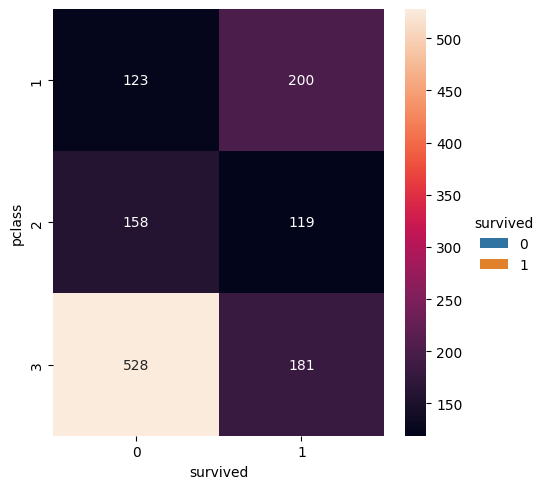

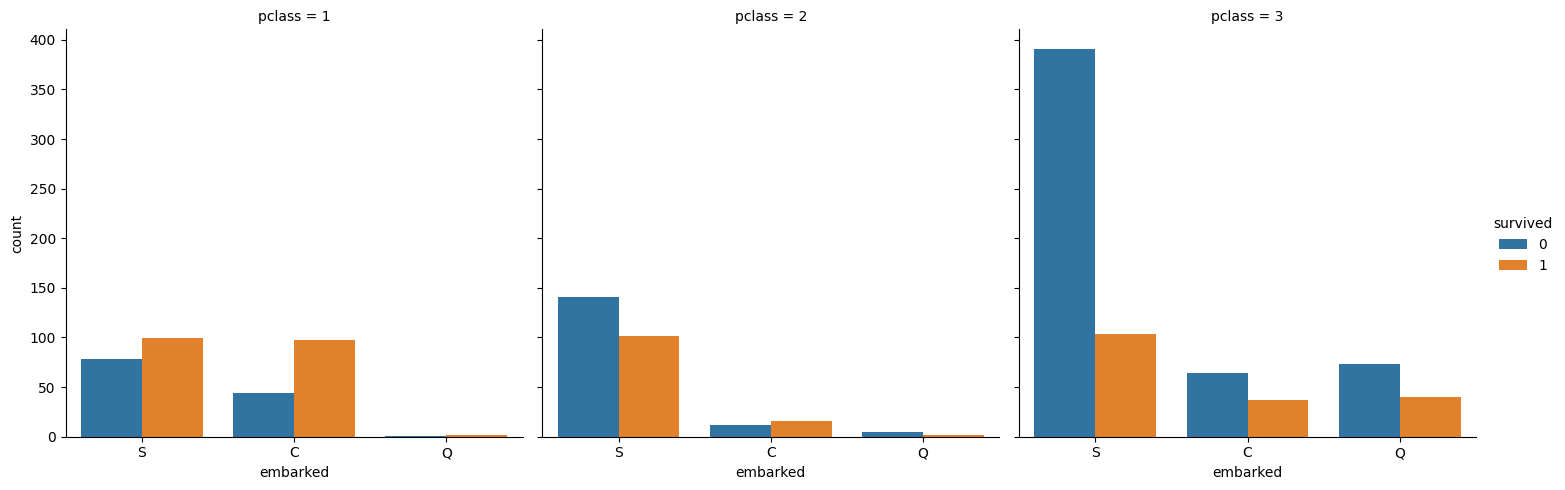

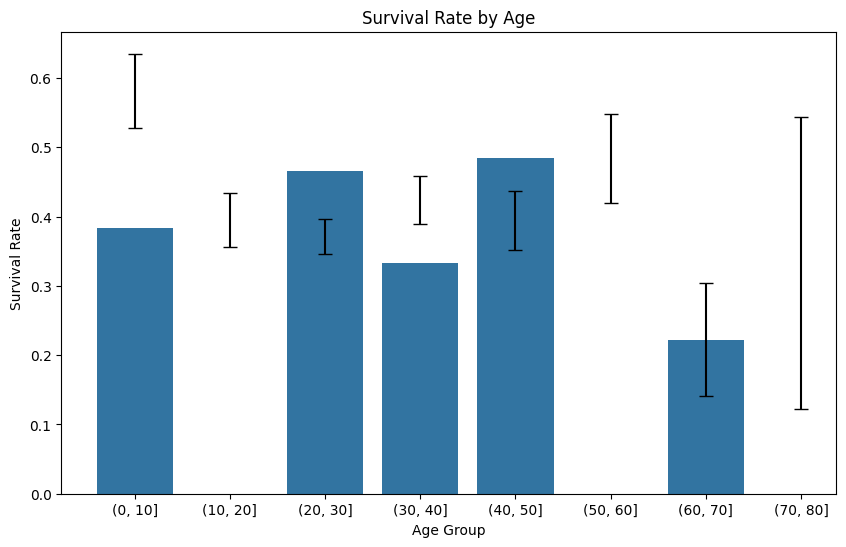

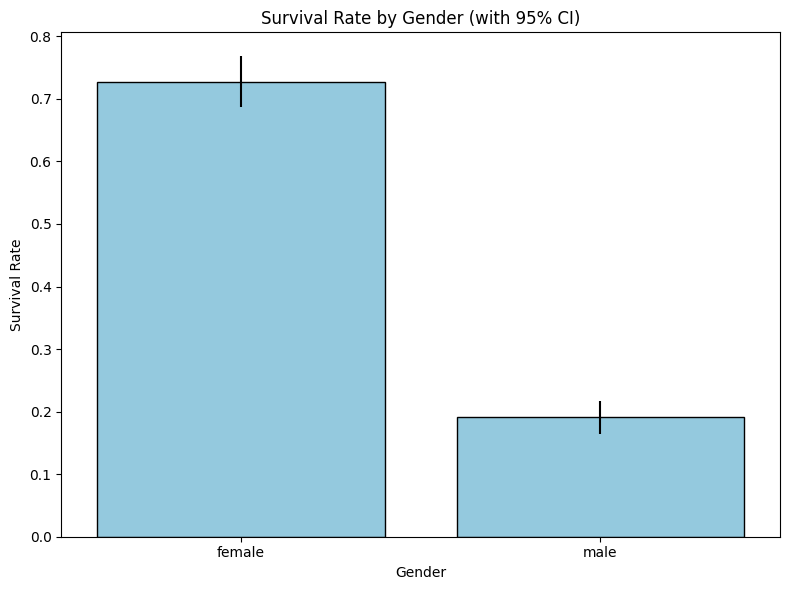

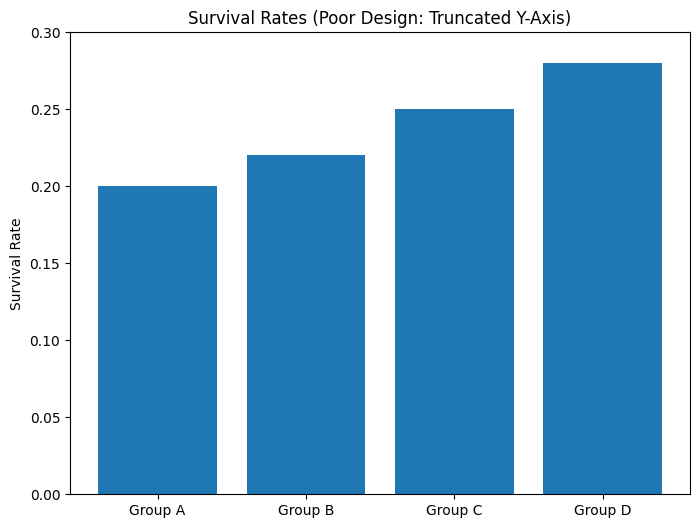

In [ ]:
#importing pandas library
import pandas as pd

#loading data
titanic = pd.read_csv(f"{path}/Titanic Dataset.csv")

#display header
display(titanic.head())

titanic.isnull().sum()

import seaborn as sns
import matplotlib.pyplot as plt

# Countplot
sns.catplot(x ="sex", hue ="survived",
kind ="count", data = titanic)

# Group the dataset by Pclass and Survived and then unstack them
group = titanic.groupby(['pclass', 'survived'])
pclass_survived = group.size().unstack()

# Heatmap - Color encoded 2D representation of data.
sns.heatmap(pclass_survived, annot = True, fmt ="d")

titanic.info()

# Countplot
sns.catplot(x ='embarked', hue ='survived',
kind ='count', col ='pclass', data = titanic)

import numpy as np

# Create a histogram of age
age_bins = np.arange(0, 101, 10)
age_groups = pd.cut(titanic['age'], bins=age_bins)

# Group by age and calculate survival rate
age_survival = titanic.groupby(age_groups)['survived'].mean().reset_index()

# Calculate confidence intervals (standard error of the mean)
age_survival['ci'] = titanic.groupby(age_groups)['survived'].sem().reset_index()['survived']

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=age_groups, y='survived', data=age_survival, errorbar=None) # Disable seaborn's internal errorbar calculation

# Add error bars manually using the pre-calculated 'ci' (standard error)
# The x-coordinates for the bars are 0, 1, 2, ... len(age_survival)-1
ax.errorbar(x=range(len(age_survival)), y=age_survival['survived'],
            yerr=age_survival['ci'], fmt='none', c='black', capsize=5)

plt.title('Survival Rate by Age')
plt.ylabel('Survival Rate')
plt.xlabel('Age Group')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Compute survival rate and standard error by gender
gender_stats = (
    titanic.groupby('sex')['survived']
    .agg(['mean', 'sem'])
    .reset_index()
    .rename(columns={'mean': 'survival_rate', 'sem': 'ci'})
)

# Plot with manual 95% CI error bars
plt.figure(figsize=(8, 6))
sns.barplot(
    x='sex',
    y='survival_rate',
    data=gender_stats,
    yerr=gender_stats['ci'] * 1.96,   # 95% CI
    color='skyblue',
    edgecolor='black'
)

plt.title('Survival Rate by Gender (with 95% CI)')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Example data (survival rates for different groups)
groups = ['Group A', 'Group B', 'Group C', 'Group D']
survival_rates = [0.2, 0.22, 0.25, 0.28]

# Plot with a truncated Y-axis (misleading)
plt.figure(figsize=(8, 6))
plt.bar(groups, survival_rates)
plt.ylim(0, 0.3)  # Truncated Y-axis (only shows 0 to 0.3)
plt.title('Survival Rates (Poor Design: Truncated Y-Axis)')
plt.ylabel('Survival Rate')
plt.show()


This code snippet:
* `import pandas as pd`: Imports the pandas library, commonly aliased as `pd`.
* `df = pd.read_csv('your_file.csv')`: Reads the CSV file located at `'your_file.csv'` and loads its content into a pandas DataFrame named `df`.
* `display(df.head())`: Shows the first 5 rows of the DataFrame, which is useful for a quick preview of your data.


=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       144
           1       0.83      0.65      0.73       118

    accuracy                           0.78       262
   macro avg       0.79      0.77      0.77       262
weighted avg       0.79      0.78      0.78       262

Confusion Matrix:
 [[128  16]
 [ 41  77]]


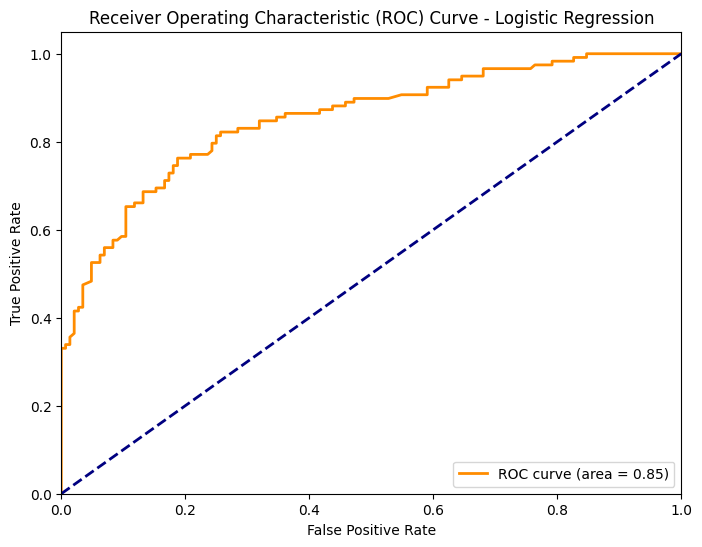

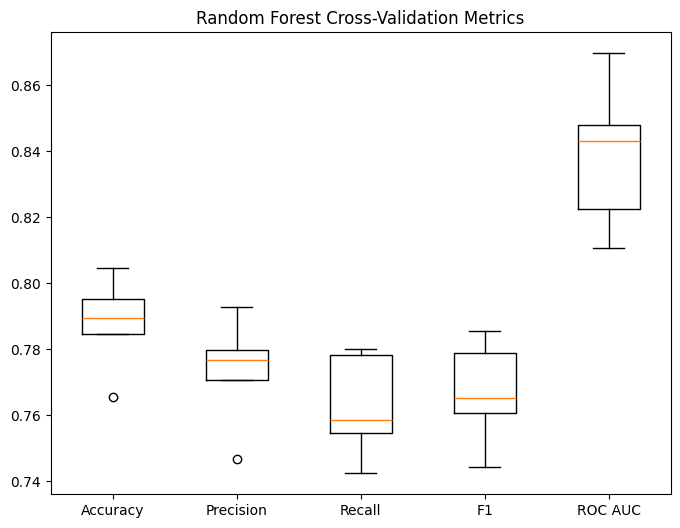


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       144
           1       0.81      0.69      0.75       118

    accuracy                           0.79       262
   macro avg       0.79      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262

Confusion Matrix:
 [[125  19]
 [ 36  82]]


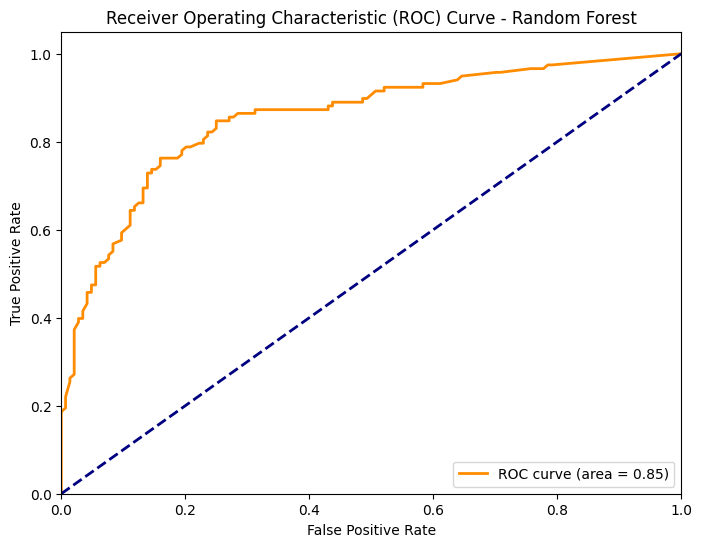

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import scikitplot as skplt # Removed due to incompatibility with scipy

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # Added roc_curve, auc

# Define the path to the dataset
path = '.' # Assuming 'Titanic Dataset.csv' is in the current working directory

# Load Titanic dataset
titanic = pd.read_csv(f"{path}/Titanic Dataset.csv")

# Drop unnecessary columns if present
drop_cols = ['name','ticket','cabin','boat','body','home.dest']
titanic = titanic.drop(columns=[c for c in drop_cols if c in titanic.columns])

# Encode categorical variables
titanic['sex'] = titanic['sex'].map({'female': 1, 'male': 0})

# Handle missing 'embarked' values before mapping
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 'pclass' column from the CSV is numeric, no need to map 'class' strings
# The original code might have intended to map a 'class' column if it came from a different source like sns.load_dataset
# Removed: titanic['class'] = titanic['class'].map({'First': 1, 'Second': 2, 'Third': 3})

# 'deck' column does not exist directly in 'Titanic Dataset.csv', it's usually derived from 'cabin'.
# Removed this line to avoid KeyError or incorrect processing:
# if 'deck' in titanic.columns:
#     titanic['deck'] = titanic['deck'].fillna('Unknown').map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'H':8})

# Handle missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['sibsp'] = titanic['sibsp'].fillna(0)
titanic['parch'] = titanic['parch'].fillna(0)
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median()) # Added this line to handle missing fare values

# Ensure 'pclass' is included and convert to object type if it should be treated as categorical for one-hot encoding later
# For Logistic Regression, leaving as numeric is fine, but ensuring it's not dropped if intended as a feature

# Features and target
X = titanic.drop(columns=['survived'])
y = titanic['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression (example from a typical modeling pipeline)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_log_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

# Random Forest Classifier (example from a typical modeling pipeline)
# rf_clf = RandomForestClassifier(random_state=42)
# rf_clf.fit(X_train, y_train)
# y_pred_rf = rf_clf.predict(X_test)
# y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# print("\n=== Random Forest Report ===")
# print(classification_report(y_test, y_pred_rf))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# ROC Curve for Logistic Regression (using sklearn and matplotlib directly)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log_reg)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()


# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Cross-validation
cv_results_rf = cross_validate(rf, X_train, y_train, cv=5,
                               scoring=['accuracy','precision_macro','recall_macro','f1_macro','roc_auc'])

# Plot CV metrics
plt.figure(figsize=(8,6))
plt.boxplot([cv_results_rf['test_accuracy'], cv_results_rf['test_precision_macro'],
             cv_results_rf['test_recall_macro'], cv_results_rf['test_f1_macro'], cv_results_rf['test_roc_auc']],
            tick_labels=['Accuracy','Precision','Recall','F1','ROC AUC']) # Changed 'labels' to 'tick_labels'
plt.title("Random Forest Cross-Validation Metrics")
plt.show()

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# ROC Curve for Random Forest (using sklearn and matplotlib directly, replacing skplt.plot_roc)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       144
           1       0.83      0.65      0.73       118

    accuracy                           0.78       262
   macro avg       0.79      0.77      0.77       262
weighted avg       0.79      0.78      0.78       262

Confusion Matrix:
 [[128  16]
 [ 41  77]]


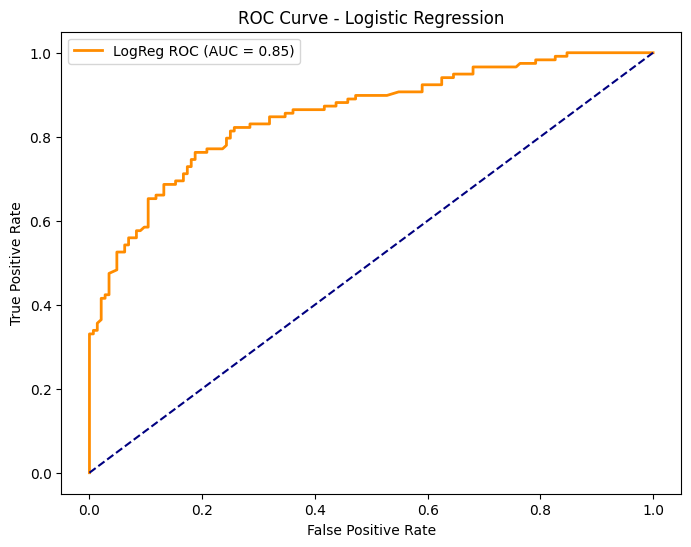


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       144
           1       0.81      0.69      0.75       118

    accuracy                           0.79       262
   macro avg       0.79      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262

Confusion Matrix:
 [[125  19]
 [ 36  82]]


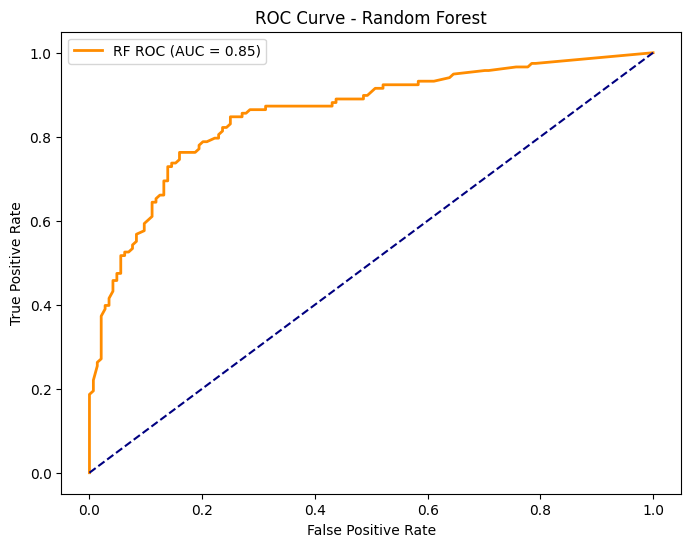

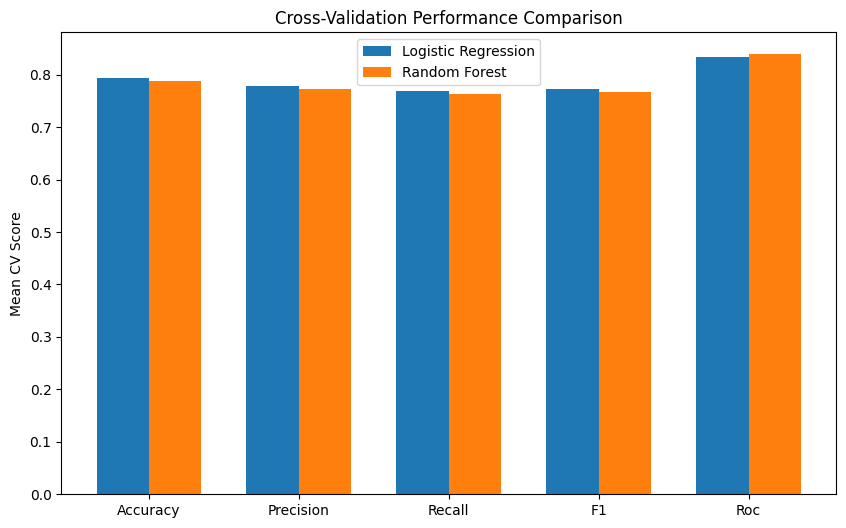

    Feature  Coefficient  Odds Ratio
1       sex     2.517148   12.393199
6  embarked     0.197332    1.218149
5      fare     0.002338    1.002341
4     parch    -0.031166    0.969314
2       age    -0.032275    0.968241
3     sibsp    -0.259500    0.771438
0    pclass    -0.935977    0.392202


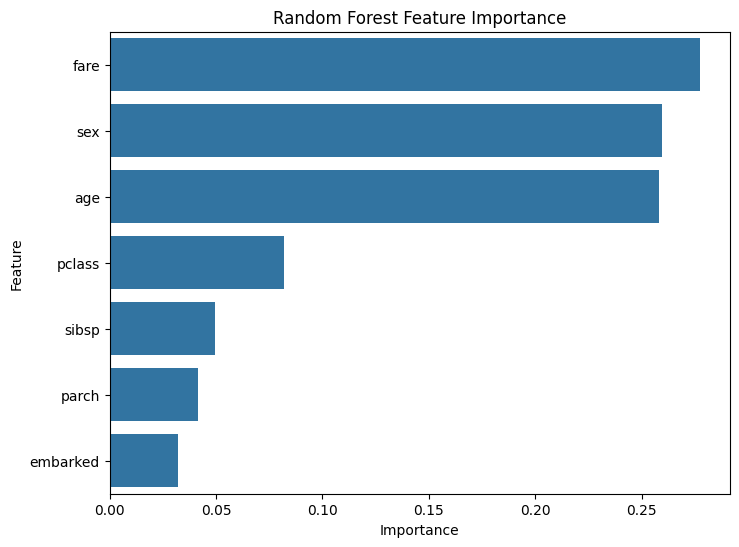

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load Titanic dataset
titanic = pd.read_csv(f"{path}/Titanic Dataset.csv")

# Drop unnecessary columns if present
drop_cols = ['name','ticket','cabin','boat','body','home.dest']
titanic = titanic.drop(columns=[c for c in drop_cols if c in titanic.columns])

# Encode categorical variables
titanic['sex'] = titanic['sex'].map({'female': 1, 'male': 0})
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Handle missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['sibsp'] = titanic['sibsp'].fillna(0)
titanic['parch'] = titanic['parch'].fillna(0)
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())

# Features and target
X = titanic.drop(columns=['survived'])
y = titanic['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Cross-validation
cv_results_log = cross_validate(log_reg, X_train, y_train, cv=5,
                                scoring=['accuracy','precision_macro','recall_macro','f1_macro','roc_auc'])

# Predictions
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_log)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LogReg ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(); plt.show()

#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Cross-validation
cv_results_rf = cross_validate(rf, X_train, y_train, cv=5,
                               scoring=['accuracy','precision_macro','recall_macro','f1_macro','roc_auc'])

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'RF ROC (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1],[0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(); plt.show()

import numpy as np

# Collect mean CV scores
metrics = ['test_accuracy','test_precision_macro','test_recall_macro','test_f1_macro','test_roc_auc']
log_means = [np.mean(cv_results_log[m]) for m in metrics]
rf_means = [np.mean(cv_results_rf[m]) for m in metrics]

# Plot side-by-side bars
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, log_means, width, label='Logistic Regression')
plt.bar(x + width/2, rf_means, width, label='Random Forest')

plt.xticks(x, [m.split("_")[1].capitalize() for m in metrics])
plt.ylabel("Mean CV Score")
plt.title("Cross-Validation Performance Comparison")
plt.legend()
plt.show()

# Logistic Regression Coefficients
coef = log_reg.coef_[0]
features = X.columns
odds_ratios = np.exp(coef)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)

print(coef_df)

# Random Forest Feature Importance
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Random Forest Feature Importance")
plt.show()


